In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('World University Rankings 2023-selected-columns.csv')

In [3]:
df

,University Rank,Name of University,Location,No of student,No of student per staff,International Student,Female:Male Ratio,OverAll Score,Teaching Score,Research Score
0,1,University of Oxford,United Kingdom,"20,965",10.6,42%,48 : 52,96.4,92.3,99.7
1,2,Harvard University,United States,"21,887",9.6,25%,50 : 50,95.2,94.8,99.0
2,3,University of Cambridge,United Kingdom,"20,185",11.3,39%,47 : 53,94.8,90.9,99.5
3,3,Stanford University,United States,"16,164",7.1,24%,46 : 54,94.8,94.2,96.7
4,5,Massachusetts Institute of Technology,United States,"11,415",8.2,33%,40 : 60,94.2,90.7,93.6
...,...,...,...,...,...,...,...,...,...,...
2336,-,University of the West of Scotland,NaN,NaN,NaN,NaN,NaN,34.0–39.2,24.1,15.5
2337,-,University of Windsor,NaN,NaN,NaN,NaN,NaN,34.0–39.2,35.1,29.4
2338,-,University of Wolverhampton,NaN,NaN,NaN,NaN,NaN,34.0–39.2,18.2,14.3
2339,-,University of Wuppertal,NaN,NaN,NaN,NaN,NaN,34.0–39.2,26.4,26.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2341 entries, 0 to 2340
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   University Rank          2341 non-null   object 
 1   Name of University       2233 non-null   object 
 2   Location                 2047 non-null   object 
 3   No of student            2209 non-null   object 
 4   No of student per staff  2208 non-null   float64
 5   International Student    2209 non-null   object 
 6   Female:Male Ratio        2128 non-null   object 
 7   OverAll Score            1799 non-null   object 
 8   Teaching Score           1799 non-null   float64
 9   Research Score           1799 non-null   float64
dtypes: float64(3), object(7)
memory usage: 183.0+ KB


In [5]:
df.duplicated().sum()

np.int64(29)

In [6]:
df.isnull().sum()

University Rank              0
Name of University         108
Location                   294
No of student              132
No of student per staff    133
International Student      132
Female:Male Ratio          213
OverAll Score              542
Teaching Score             542
Research Score             542
dtype: int64

In [7]:
df['Location']=df['Location'].fillna(df['Location'].mode()[0])

In [8]:
df.isnull().sum()

University Rank              0
Name of University         108
Location                     0
No of student              132
No of student per staff    133
International Student      132
Female:Male Ratio          213
OverAll Score              542
Teaching Score             542
Research Score             542
dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df['Research Score']=df['Research Score'].fillna(df['Research Score'].mean())

In [11]:
df['No of student']

0       20,965
1       21,887
2       20,185
3       16,164
4       11,415
         ...  
2336       NaN
2337       NaN
2338       NaN
2339       NaN
2340       NaN
Name: No of student, Length: 2341, dtype: object

In [12]:
df['No of student']=df['No of student'].fillna(df['No of student'].mode()[0])

In [13]:
df['Teaching Score']=df['Teaching Score'].fillna(df['Teaching Score'].mean())

In [14]:
df['OverAll Score']=df['OverAll Score'].fillna(df['OverAll Score'].mode()[0])

In [15]:
df['No of student per staff']=df['No of student per staff'].fillna(df['No of student per staff'].median())

In [16]:
df['International Student']=df['International Student'].fillna(df['International Student'].mode()[0])

In [17]:
df['Female:Male Ratio']=df['Female:Male Ratio'].fillna(df['Female:Male Ratio'].mode()[0])


In [18]:
df['Name of University']=df['Name of University'].fillna(df['Name of University'].mode()[0])

In [19]:
df.describe()

,No of student per staff,Teaching Score,Research Score
count,2341.000000,2341.000000,2341.000000
mean,18.864032,27.018010,23.016898
std,11.795498,11.642824,14.694671
min,0.400000,11.600000,7.400000
25%,12.800000,19.000000,12.700000
50%,16.600000,27.018010,22.900000
75%,21.700000,28.400000,24.200000
max,232.200000,94.800000,99.700000


<Axes: ylabel='No of student per staff'>

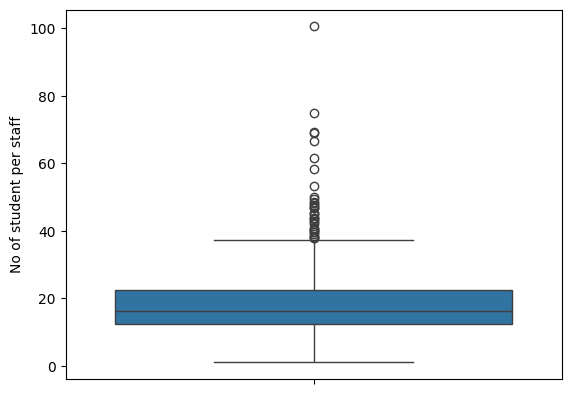

In [20]:
sns.boxplot(df['No of student per staff'].head(700))

<Axes: ylabel='Research Score'>

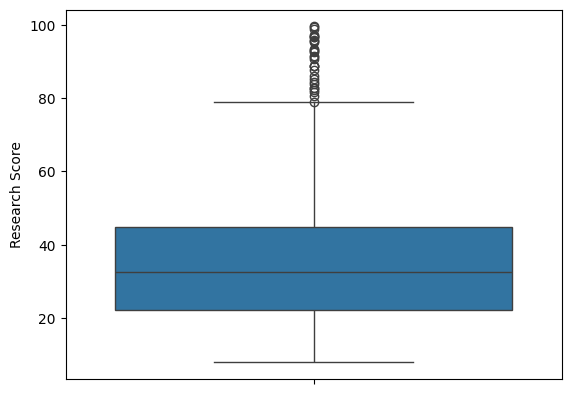

In [21]:
sns.boxplot(df['Research Score'].head(700))

<Axes: ylabel='Teaching Score'>

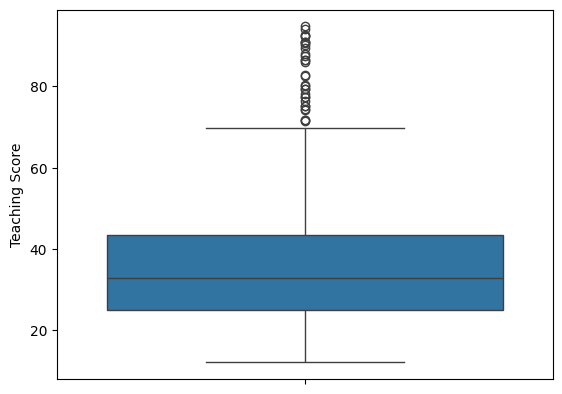

In [22]:
sns.boxplot(df['Teaching Score'].head(700))

In [23]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['No of student per staff']))
df_clean = df[z_scores < 2] 

print(df.describe()) 

       No of student per staff  Teaching Score  Research Score
count              2341.000000     2341.000000     2341.000000
mean                 18.864032       27.018010       23.016898
std                  11.795498       11.642824       14.694671
min                   0.400000       11.600000        7.400000
25%                  12.800000       19.000000       12.700000
50%                  16.600000       27.018010       22.900000
75%                  21.700000       28.400000       24.200000
max                 232.200000       94.800000       99.700000


In [24]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['Teaching Score']))
df_clean = df[z_scores < 2] 

print(df.describe()) 

       No of student per staff  Teaching Score  Research Score
count              2341.000000     2341.000000     2341.000000
mean                 18.864032       27.018010       23.016898
std                  11.795498       11.642824       14.694671
min                   0.400000       11.600000        7.400000
25%                  12.800000       19.000000       12.700000
50%                  16.600000       27.018010       22.900000
75%                  21.700000       28.400000       24.200000
max                 232.200000       94.800000       99.700000


In [25]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(df['Research Score']))
df_clean = df[z_scores < 2] 

print(df_clean.describe()) 

       No of student per staff  Teaching Score  Research Score
count              2219.000000     2219.000000     2219.000000
mean                 18.929067       25.061902       20.428057
std                  11.828088        7.601526        9.401798
min                   0.400000       11.600000        7.400000
25%                  13.000000       18.800000       12.400000
50%                  16.600000       26.100000       21.400000
75%                  21.800000       27.018010       23.016898
max                 232.200000       59.800000       52.300000


<Axes: xlabel='Research Score', ylabel='Density'>

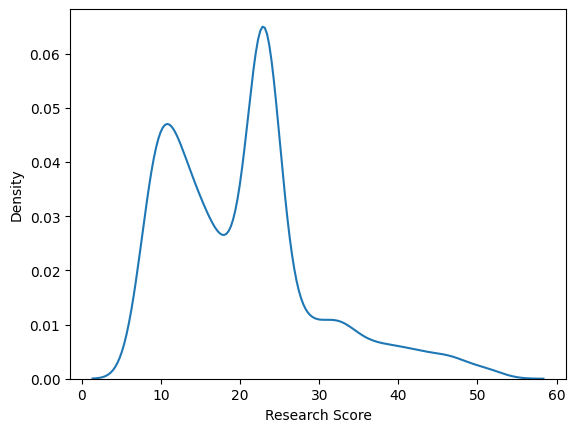

In [27]:
sns.kdeplot(df_clean['Research Score'])

<Axes: ylabel='Research Score'>

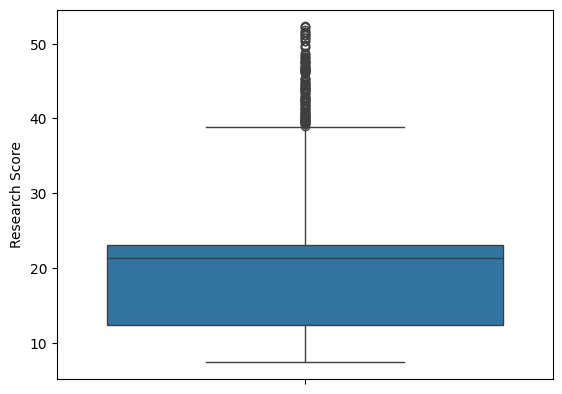

In [30]:
sns.boxplot(df_clean['Research Score'])

In [29]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))


Original rows: 2341
Cleaned rows: 2219
Rows removed: 122
